## Random Forest model

In [116]:
# Cargar el archivo CSV
import pandas as pd
import numpy as np
import error_metrics
import pipeline

csv_path = "../DataFinal.csv"
df = pd.read_csv(csv_path)
print(df.shape)

(117, 45)


## Train/Test

In [ ]:
from sklearn.model_selection import train_test_split
data = df.copy()
target = data.pop('Total Nacimientos')
X_train, X_test, y_train, y_test = train_test_split(
    data, 
    target, 
    test_size=0.2, 
    shuffle=False, 
    random_state=61023521)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(93, 44) (93,)
(24, 44) (24,)


## Pipeline

In [118]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer


num_cols = data.select_dtypes(exclude=['object']).columns
cat_cols = data.select_dtypes(include=['object']).columns
numeric_preprocessor = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
)
categorical_preprocessor = OneHotEncoder(handle_unknown="ignore")

preprocessor= ColumnTransformer([
    ('one_hot_encoder',categorical_preprocessor,cat_cols),
    ('numerico', numeric_preprocessor,num_cols)
],remainder="passthrough")


## Modelo Inicial

In [152]:
import matplotlib.pyplot as plt
seed = 641234

def plot_predictions(y_test, y_pred, title):
    y_test_graph = y_test.reset_index(drop=True)
    plt.title(title)
    plt.plot(y_pred, '-o', label="Predicción")
    plt.plot(y_test_graph,'-x', label="Original")
    plt.xlabel("Indice")
    plt.ylabel("Total de Nacimientos")
    plt.legend()
    plt.show()

## Params:


In [122]:
#  'randomforestregressor__max_depth': None,
#  'randomforestregressor__n_estimators': 100,
#  'randomforestregressor__min_samples_leaf': 1,
#  'randomforestregressor__min_samples_split': 2,
#  'randomforestregressor__max_features': 1.0,
#  'randomforestregressor__bootstrap': True,
#  'randomforestregressor__criterion': 'squared_error',

## Model 1

In [153]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
rf_1 = make_pipeline(preprocessor, RandomForestRegressor(random_state=seed))
param_grid = {
    'randomforestregressor__max_depth': [5,10,20,30],
    "randomforestregressor__bootstrap": [True, False],
    'randomforestregressor__n_estimators': [50,100,150,200],
    'randomforestregressor__max_features': ['sqrt', 'log2', 1.0]
}
gs1 = GridSearchCV(
    rf_1,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

gs1.fit(X_train, y_train)
best_model1= gs1.best_estimator_
print("Best Params: ",gs1.best_params_)
print("Best RMSE", np.sqrt(-gs1.best_score_))


Best Params:  {'randomforestregressor__bootstrap': False, 'randomforestregressor__max_depth': 10, 'randomforestregressor__max_features': 'sqrt', 'randomforestregressor__n_estimators': 50}
Best RMSE 2996.9019385884585


Random Forest #1:
MAE: 7262.756666666665
MSE: 98229462.09859999
RMSE: 9911.077746572266
R²: 0.9246258933184001


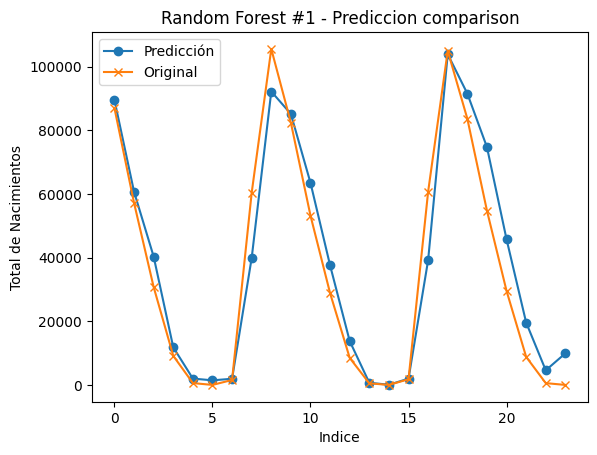

In [154]:
y_rf_1 = best_model1.predict(X_test)
error_metrics.calculate_errors(y_rf_1, y_test, "Random Forest #1")
plot_predictions(y_test, y_rf_1, "Random Forest #1 - Prediccion comparison")

### Overfitting

In [149]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
def ovefitting_test(model):
    y_pred = best_model1.predict(X_test)
    val_mse = np.sqrt(mean_squared_error(y_test, y_pred))
        
    cv_scores = cross_val_score(
        model, 
        X_train, 
        y_train, 
        cv=5, 
        scoring='neg_mean_squared_error',
    )
    train_rsme= np.sqrt(-cv_scores.mean())
    overfit_ratio = val_mse / train_rsme
    print(f"Train RMSE: {train_rsme:.4f}")
    print(f"Validation RMSE: {val_mse:.4f}")
    print(f"Overfit Ratio (val/train): {overfit_ratio:.2f}")

ovefitting_test(best_model1)

Train RMSE: 3302.0959
Validation RMSE: 17355.1359
Overfit Ratio (val/train): 5.26


## Modelo 2

In [142]:
rf_2 = make_pipeline(preprocessor, RandomForestRegressor())
param_grid = {
    'randomforestregressor__max_depth': [5,10,20,30],
    'randomforestregressor__criterion':[ 'squared_error', 'absolute_error', 'friedman_mse', 'poisson'],
}
gs2 = GridSearchCV(
    rf_2,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

gs2.fit(X_train, y_train)
best_model2= gs2.best_estimator_
print("Best Params: ",gs2.best_params_)
print("Best RMSE", np.sqrt(-gs2.best_score_))

Best Params:  {'randomforestregressor__criterion': 'poisson', 'randomforestregressor__max_depth': 30}
Best RMSE 3206.2399099598056


Random Forest #2:
MAE: 6313.794166666667
MSE: 77092019.40804166
RMSE: 8780.206114211765
R²: 0.9408452212704876


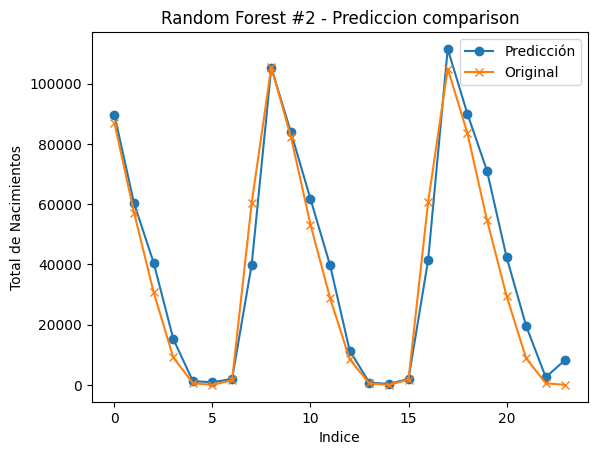

In [155]:
y_rf_2 = best_model2.predict(X_test)
error_metrics.calculate_errors(y_rf_2, y_test, "Random Forest #2")
plot_predictions(y_test, y_rf_2, "Random Forest #2 - Prediccion comparison")

In [157]:
ovefitting_test(best_model2)

Train RMSE: 3345.3274
Validation RMSE: 9911.0777
Overfit Ratio (val/train): 2.96


## Modelo 3

In [159]:
rf_3 = make_pipeline(preprocessor, RandomForestRegressor(random_state=seed))
param_grid = {
    'randomforestregressor__max_depth': [5,10,20,30],
    "randomforestregressor__bootstrap": [True, False],
    'randomforestregressor__max_depth': [5,10,20,30],
    'randomforestregressor__min_samples_leaf': [1,2, 4],
    'randomforestregressor__min_samples_split': [2,5,7],
}
gs3 = GridSearchCV(
    rf_3,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

gs3.fit(X_train, y_train)
best_model3= gs3.best_estimator_
print("Best Params: ",gs3.best_params_)
print("Best RMSE", np.sqrt(-gs3.best_score_))

Best Params:  {'randomforestregressor__bootstrap': False, 'randomforestregressor__max_depth': 10, 'randomforestregressor__min_samples_leaf': 1, 'randomforestregressor__min_samples_split': 2}
Best RMSE 3393.2167316059704


Random Forest #2:
MAE: 9795.101944444436
MSE: 301301663.9448709
RMSE: 17358.04320610105
R²: 0.7688031342498012


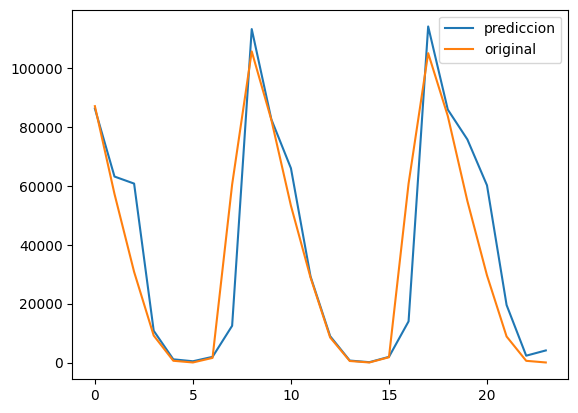

In [130]:
y_rf_3 = best_model3.predict(X_test)
error_metrics.calculate_errors(y_rf_3, y_test, "Random Forest #2")
plot_predictions(y_test, y_rf_3)

In [131]:
ovefitting_test(gs3.best_params_)

Train RMSE: 3376.2470
Validation RMSE: 10232.3615
Overfit Ratio (val/train): 3.03
